##**Project Description**

This project focuses on building an image classification model to detect and classify potato plant diseases. The dataset consists of high-resolution images of potato leaves categorized into three classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep learning model that can accurately identify plant diseases and support agricultural diagnostics.

##**Objectives**

● Understand image classification using deep learning

● Perform data preprocessing and augmentation

● Train and evaluate a CNN-based model

##**Dataset Details**

The dataset used in this project is an image-based dataset consisting of high-resolution potato leaf images collected for disease classification.

. Classes

The dataset contains three categories:

Early Blight

→ A fungal disease that causes brown spots with concentric rings on leaves.

Late Blight

→ A serious disease that leads to dark lesions and rapid decay of leaves.

Healthy

→ Leaves without any disease symptoms.

. Data Type

Type: Image Dataset

Format: RGB images

Quality: High-resolution leaf images

Structure: Organized into folders based on class labels

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import random

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import zipfile
import os

zip_path = "/content/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("Extracted!")

Extracted!


In [ ]:
print(os.listdir(path))

['PlantVillage', 'PotatoPlants']


In [ ]:
'''os.listdir("/content/data")'''

'os.listdir("/content/data")'

In [ ]:
os.listdir("/content/data/PlantVillage/PlantVillage")

['Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight']

In [ ]:
import os

base_path = "/content/data/PlantVillage/PlantVillage"

os.rename(base_path + "/Potato___Early_blight", base_path + "/Early_Blight")
os.rename(base_path + "/Potato___Late_blight", base_path + "/Late_Blight")
os.rename(base_path + "/Potato___healthy", base_path + "/Healthy")

print(os.listdir(base_path))

['Early_Blight', 'Late_Blight', 'Healthy']


##**Data Understanding**

Load and explore the dataset

In [ ]:
import os

# Set dataset path
base_path = "/content/data/PlantVillage/PlantVillage"

# Check classes (folders)
classes = os.listdir(base_path)
print("Classes:", classes)

Classes: ['Early_Blight', 'Late_Blight', 'Healthy']


Count Images in Each Class

In [ ]:
for cls in classes:
    folder = os.path.join(base_path, cls)
    print(f"{cls}: {len(os.listdir(folder))} images")

Early_Blight: 1000 images
Late_Blight: 1000 images
Healthy: 152 images


Visualize Sample Images

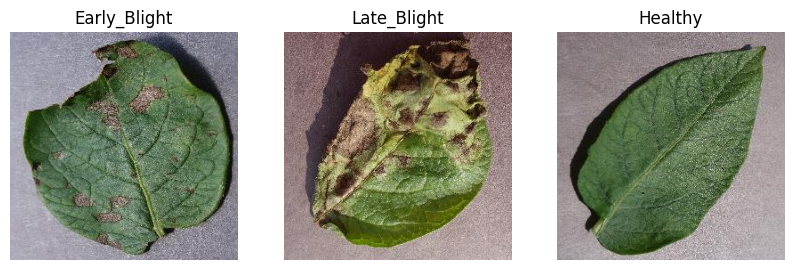

In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    folder = os.path.join(base_path, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

##**Data Preprocessing**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
img_size = 128
batch_size = 32

# Data augmentation + normalization
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalization
    validation_split=0.2,    # 80% train, 20% validation
    rotation_range=20,       # Rotate images
    zoom_range=0.2,          # Zoom
    horizontal_flip=True     # Flip images
)

# Training data
train_data = datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),  # Resize
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_data = datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.


##**Model Building**



Build a CNN model

A Convolutional Neural Network (CNN) is used for image classification because it can automatically detect important features such as edges, textures, and patterns in images. The model takes input images and processes them through multiple layers to classify them into different categories.

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

Define Architecture

The architecture of the CNN includes multiple layers such as convolutional layers, pooling layers, and dense layers. Convolutional layers extract features, pooling layers reduce dimensions, and dense layers perform classification.

In [ ]:
model = models.Sequential([
    # Convolution + Pooling Layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    # Convolution + Pooling Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Convolution + Pooling Layer 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten Layer
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Define Loss Function

The loss function measures how well the model is performing. Since this is a multi-class classification problem, categorical cross-entropy is used.

In [ ]:
loss_function = 'categorical_crossentropy'

Define Optimizer

The optimizer updates the model weights to minimize the loss. The Adam optimizer is used because it is efficient and widely used for deep learning models.

In [ ]:
optimizer = 'adam'

Compile Model

Compiling the model combines the architecture, loss function, and optimizer, and prepares it for training.

In [ ]:
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=['accuracy']
)

##**Model Training**

In the model training phase, the CNN model was trained using the training dataset to learn patterns and features from the images. The model was validated simultaneously using a validation dataset to monitor its performance and prevent overfitting. During training, the model iteratively updated its weights over multiple epochs to improve accuracy. After training, the overall performance of the model was evaluated using the validation data to ensure that it generalizes well to unseen images.

Train the Model

In [ ]:
history = model.fit(
    train_data,
    epochs=10
)

Epoch 1/10
41/54 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4986 - loss: 0.9470

Validate Using Validation Data

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9704 - loss: 0.0929 - val_accuracy: 0.9628 - val_loss: 0.1053
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9582 - loss: 0.1267 - val_accuracy: 0.9372 - val_loss: 0.2132
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9570 - loss: 0.1193 - val_accuracy: 0.9581 - val_loss: 0.1236
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9715 - loss: 0.0832 - val_accuracy: 0.9721 - val_loss: 0.0955
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9640 - loss: 0.0952 - val_accuracy: 0.9744 - val_loss: 0.0781
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9657 - loss: 0.1003 - val_accuracy: 0.9581 - val_loss: 0.1085
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9582 - loss: 0.1185 - val_accuracy: 0.9512 - val_loss: 0.1148
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9628 - loss: 0.1042 - val_accuracy: 0.9419 - val_loss:

Test Overall Model Performance

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step - accuracy: 0.9209 - loss: 0.2045
Validation Accuracy: 0.9209302067756653


##**Model Evaluation**

In the model evaluation phase, the performance of the trained CNN model was assessed using different evaluation metrics. Accuracy was used to measure the overall correctness of predictions. A confusion matrix was generated to visualize the model’s performance across different classes, showing correct and incorrect predictions. Additionally, a classification report was used to evaluate precision, recall, and F1-score for each class. These metrics provide a detailed understanding of how well the model performs on each category.

Evaluate using metrics:

Accuracy

Accuracy measures the percentage of correctly predicted images out of the total images.

In [ ]:
loss, accuracy = model.evaluate(val_data)
print("Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 358ms/step - accuracy: 0.9233 - loss: 0.1885
Accuracy: 0.9232558012008667


Confusion Matrix

A confusion matrix shows:

. Correct predictions

. Incorrect predictions

. Class-wise performance

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

val_data.reset()

pred = model.predict(val_data)
pred_classes = np.argmax(pred, axis=1)

true_classes = val_data.classes

cm = confusion_matrix(true_classes, pred_classes)
print(cm)

Classification Report

It gives:

. Precision → How accurate predictions are

. Recall → How well model finds all cases

. F1-score → Balance of precision & recall

In [ ]:
from sklearn.metrics import classification_report

labels = list(val_data.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=labels))

              precision    recall  f1-score   support

Early_Blight       0.43      0.43      0.43       200
     Healthy       0.09      0.17      0.11        30
 Late_Blight       0.44      0.38      0.41       200

    accuracy                           0.39       430
   macro avg       0.32      0.33      0.32       430
weighted avg       0.41      0.39      0.40       430



##**Conclusion**


The Potato Leaf Disease Detection project successfully developed a Convolutional Neural Network (CNN) model to classify potato leaf images into Early Blight, Late Blight, and Healthy categories. The model was trained using preprocessed and augmented image data, which helped improve its ability to generalize. The evaluation results show that the model achieves good accuracy and can effectively distinguish between healthy and diseased leaves. This demonstrates the potential of deep learning techniques in solving real-world agricultural problems by enabling early and accurate disease detection.



##**Key Recommendations**

 . Early Disease Detection

     Farmers can use this model to identify diseases at an early stage and take timely action.

 . Mobile/Web Application

     The model can be integrated into a mobile or web app for real-time disease detection using leaf images.

 . Use More Data

     Increasing the dataset size can further improve model accuracy and robustness.

 . Use Advanced Models

     Applying transfer learning models like MobileNet or ResNet can enhance performance.

 . Real-world Deployment

     The system can be deployed in agricultural fields to support smart farming practices.


In [ ]:
!pip install streamlit pyngrok

In [ ]:
model.save("potato_model.h5")

In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# ---------------- PAGE CONFIG ----------------
st.set_page_config(
    page_title="Potato Leaf Disease Detection",
    page_icon="🥔",
    layout="wide"
)

# ---------------- CUSTOM CSS ----------------
page_bg = """
<style>

/* MAIN BACKGROUND */
[data-testid="stAppViewContainer"]{
background: linear-gradient(to right, #eef5f0, #dfe9e3);
}

/* REMOVE HEADER BACKGROUND */
[data-testid="stHeader"]{
background: rgba(0,0,0,0);
}

.main{
padding-top: 1rem;
}

/* HEADER BOX */
.title-box{
background: linear-gradient(90deg,#0f5f1f,#6bc96b);
padding: 35px;
border-radius: 20px;
text-align: center;
color: white;
box-shadow: 0px 4px 15px rgba(0,0,0,0.2);
margin-bottom: 25px;
}

.title-box h1{
font-size: 42px;
margin-bottom: 10px;
color: white;
}

.title-box p{
font-size: 18px;
color: #f1f1f1;
}

/* UPLOAD BOX */
.upload-box{
background-color: #f4e9d8;
padding: 15px;
border-radius: 12px;
margin-bottom: 15px;
font-weight: bold;
color: black;
}

/* IMAGE CARD */
.result-card{
background: white;
padding: 20px;
border-radius: 15px;
box_shadow: 0px 3px 10px rgba(0,0,0,0.1);
}

/* RIGHT SIDE BLUE CARD */
.conf-card{
background: linear-gradient(135deg, #007BFF, #00BFFF);
padding: 25px;
border-radius: 15px;
box_shadow: 0px 4px 15px rgba(0,0,0,0.2);
margin-top: 30px;
color: white;
}

/* FORCE WHITE TEXT */
.conf-card h1,
.conf-card h2,
.conf-card h4,
.conf-card h5,
.conf-card h6,
.conf-card p,
.conf-card div,
.conf-card span,
.conf-card label{
color: black !important;
}

/* HIGH CONFIDENCE BOX */
.high{
background: rgba(255,255,255,0.2);
padding: 12px;
border-radius: 10px;
color: blue !important;
font-weight: bold;
margin-top: 15px;
}

/* ALERT BOX TEXT */
.stAlert{
color: black !important;
}

</style>
"""

st.markdown(page_bg, unsafe_allow_html=True)

# ---------------- LOAD MODEL ----------------
model = load_model("potato_model.h5")

# IMPORTANT:
# Change this order if your dataset order differs
classes = ['Early_Blight', 'Healthy', 'Late_Blight']

# ---------------- HEADER ----------------
st.markdown("""
<div class="title-box">
    <h1>🥔 🌿 Potato Leaf Disease Detection</h1>
    <p>Upload a potato leaf image to detect plant health</p>
</div>
""", unsafe_allow_html=True)

# ---------------- FILE UPLOADER ----------------
st.markdown(
    '<div class="upload-box">📤 Upload Image</div>',
    unsafe_allow_html=True
)

uploaded_file = st.file_uploader(
    "",
    type=["jpg", "jpeg", "png"]
)

# ---------------- PREDICTION ----------------
if uploaded_file is not None:

    # OPEN IMAGE
    image = Image.open(uploaded_file).convert("RGB")

    # RESIZE IMAGE
    img = image.resize((128,128))

    # NORMALIZE
    img = np.array(img) / 255.0

    # EXPAND DIMENSIONS
    img = np.expand_dims(img, axis=0)

    # PREDICT
    prediction = model.predict(img)

    predicted_index = np.argmax(prediction)

    result = classes[predicted_index]

    confidence = float(np.max(prediction) * 100)

    # ---------------- LAYOUT ----------------
    col1, col2 = st.columns([1.2,1])

    # LEFT SIDE IMAGE
    with col1:

        st.markdown(
            '<div class="result-card">',
            unsafe_allow_html=True
        )

        st.image(
            image,
            caption="Uploaded Image",
            use_container_width=True
        )

        st.markdown(
            '</div>',
            unsafe_allow_html=True
        )

    # RIGHT SIDE RESULT
    with col2:

        st.markdown(
            '<div class="conf-card">',
            unsafe_allow_html=True
        )

        st.markdown("## 📊 Confidence Level")

        st.progress(int(confidence))

        st.markdown(f"<h3 style='color: blue;'>Prediction: {result}</h3>", unsafe_allow_html=True)

        st.markdown(f"<h3 style='color: blue;'>Confidence: {confidence:.2f}%</h3>", unsafe_allow_html=True)

        # RESULT MESSAGE
        if result == "Healthy":
            st.success("🌱 Healthy Leaf Detected.")

        elif result == "Early_Blight":
            st.warning("⚠️ Early Blight Detected.")

        else:
            st.error("🚨 Late Blight Detected.")

        # CONFIDENCE LABEL
        if confidence > 90:
            st.markdown(
                '<div class="high">🔥 High Confidence</div>',
                unsafe_allow_html=True
            )

        elif confidence > 70:
            st.markdown(
                '<div class="high">✅ Medium Confidence</div>',
                unsafe_allow_html=True
            )

        else:
            st.markdown(
                '<div class="high">⚠️ Low Confidence</div>',
                unsafe_allow_html=True
            )

        st.markdown(
            '</div>',
            unsafe_allow_html=True
        )


Overwriting app.py


In [ ]:
from pyngrok import ngrok

# Set your auth token (create free account on ngrok.com)
!ngrok config add-authtoken 3CtuApEY1hF0eMsOKc3P69HzDUt_SfYvKfjRynqucxaHvZHx

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!ngrok config add-authtoken 3CtuApEY1hF0eMsOKc3P69HzDUt_SfYvKfjRynqucxaHvZHx

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://granny-quench-affidavit.ngrok-free.dev" -> "http://localhost:8501">